In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy.stats import gaussian_kde


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
#====================================
# Filtrando e Preparando os Dados
#====================================

# Lendo os dados
df = pd.read_csv('br_mdr_snis_municipio_agua_esgoto.csv')

# Filtrando dados de 2022
df = df[df['ano'] == 2022]

# Separando as variáveis que serão utilizadas
qualitativa = 'sigla_uf'
discreta = 'populacao_atendida_agua'
continua = 'indice_consumo_agua_per_capita'
df = df[[qualitativa, discreta, continua]]

df = df.dropna() # Removendo linhas com "NaN"

# Convertendo a variavel discreta para int
df[discreta] = df[discreta].astype(int)

df.head()

,sigla_uf,populacao_atendida_agua,indice_consumo_agua_per_capita
702,AL,32000,180.8
703,BA,33620,83.4
704,BA,152917,133.7
705,BA,5534,70.1
706,CE,58629,88.6


In [92]:
# =========================================================
# FUNÇÕES AUXILIARES
# =========================================================

def medidas_rol(serie):
    media = np.mean(serie)
    mediana = np.median(serie)
    moda = serie.mode().iloc[0]

    q1 = np.percentile(serie, 25)
    q2 = np.percentile(serie, 50)
    q3 = np.percentile(serie, 75)

    amplitude_total = np.max(serie) - np.min(serie)
    aiq = q3 - q1
    desvio = np.std(serie, ddof=1)
    cv = desvio/media

    return {'medidas': {'media': media, 'mediana': mediana, 'moda': moda},
            'quartis': {'Q1': q1, 'Q2': q2, 'Q3': q3},
            'variabilidade': {'amplitude_total': amplitude_total,
                              'AIQ': aiq,
                              'desvio_padrao': desvio,
                              'coef_variacao': cv }
    }

def exibe_quartis(nome, medidas):
    print(f"\nQuartis da variável {nome}")
    print(f"25% dos dados ≤ {medidas['Q1']:.2f}")
    print(f"50% dos dados ≤ {medidas['Q2']:.2f} (mediana)")
    print(f"75% dos dados ≤ {medidas['Q3']:.2f}")

def simetria(nome, medidas):
    if medidas['media'] > medidas['mediana']:
        print(nome,": assimetria à direita")
    elif medidas['media'] < medidas['mediana']:
        print(nome,": assimetria à esquerda")
    else:
        print(nome,": distribuição simétrica")

def pontos_medios_freq(tabela):
    pontos_medios = np.array([interval.mid for interval in tabela.index])
    freq = np.array(tabela['Freq'])
    N = freq.sum()
    return pontos_medios, freq, N

def media_agrupada(tabela):
    pm, f, N = pontos_medios_freq(tabela)
    return np.sum(pm*f)/N

def mediana_agrupada(tabela):
    N = tabela['Freq'].sum()
    freq_acum = tabela['Freq'].cumsum()

    classe_mediana = freq_acum[freq_acum >= N/2].index[0]
    idx = tabela.index.get_loc(classe_mediana)

    L = classe_mediana.left
    h = classe_mediana.length
    F_ant = freq_acum.iloc[idx-1] if idx>0 else 0
    f_classe = tabela.iloc[idx]['Freq']

    return L + ((N/2 - F_ant)/f_classe)*h

def moda_agrupada(tabela):
    idx = tabela['Freq'].idxmax()
    i = tabela.index.get_loc(idx)

    L = idx.left
    h = idx.length
    f1 = tabela.iloc[i]['Freq']
    f0 = tabela.iloc[i-1]['Freq'] if i>0 else 0
    f2 = tabela.iloc[i+1]['Freq'] if i < len(tabela)-1 else 0

    return L + ((f1-f0)/(2*f1 - f0 - f2))*h

def quartil_agrupado(tabela, k):
    N = tabela['Freq'].sum()
    pos = k*N/4
    freq_acum = tabela['Freq'].cumsum()

    classe = freq_acum[freq_acum >= pos].index[0]
    idx = tabela.index.get_loc(classe)

    L = classe.left
    h = classe.length
    F_ant = freq_acum.iloc[idx-1] if idx>0 else 0
    f_classe = tabela.iloc[idx]['Freq']

    return L + ((pos - F_ant)/f_classe)*h

def desvio_agrupado(tabela):
    pm, f, N = pontos_medios_freq(tabela)
    media = media_agrupada(tabela)
    variancia = np.sum(f*(pm-media)**2)/N
    return np.sqrt(variancia)

def comparar_medidas(nome, tabela, medidas_rol):
    print("\n==============================")
    print("Variável:", nome)

    media = media_agrupada(tabela)
    mediana = mediana_agrupada(tabela)
    moda = moda_agrupada(tabela)
    q1 = quartil_agrupado(tabela,1)
    q3 = quartil_agrupado(tabela,3)
    desvio = desvio_agrupado(tabela)

    print("MEDIA agrupada:", media)
    print("MEDIA rol:", medidas_rol['medidas']['media'])

    print("\nMEDIANA agrupada:", mediana)
    print("MEDIANA rol:", medidas_rol['medidas']['mediana'])

    print("\nMODA agrupada:", moda)
    print("MODA rol:", medidas_rol['medidas']['moda'])

    print("\nQ1 agrupado:", q1)
    print("Q1 rol:", medidas_rol['quartis']['Q1'])

    print("\nQ3 agrupado:", q3)
    print("Q3 rol:", medidas_rol['quartis']['Q3'])

    print("\nDESVIO agrupado:", desvio)
    print("DESVIO rol:", medidas_rol['variabilidade']['desvio_padrao'])

In [93]:
# =========================================================
# a) MEDIDAS COM BASE NO ROL
# =========================================================

medidas_discreta = medidas_rol(df[discreta])
medidas_continua = medidas_rol(df[continua])

print("POPULAÇÃO ATENDIDA (DISCRETA)")
for k,v in medidas_discreta['medidas'].items():
    print(k,":",v)

print("\nCONSUMO PER CAPITA (CONTÍNUA)")
for k,v in medidas_continua['medidas'].items():
    print(k,":",v)

POPULAÇÃO ATENDIDA (DISCRETA)
media : 31601.925693160814
mediana : 7167.5
moda : 4000

CONSUMO PER CAPITA (CONTÍNUA)
media : 149.9098336414048
mediana : 135.4
moda : 111.8


In [94]:
# =========================================================
# b) QUARTIS
# =========================================================

exibe_quartis(discreta, medidas_discreta['quartis'])
exibe_quartis(continua, medidas_continua['quartis'])


Quartis da variável populacao_atendida_agua
25% dos dados ≤ 3272.00
50% dos dados ≤ 7167.50 (mediana)
75% dos dados ≤ 18022.00

Quartis da variável indice_consumo_agua_per_capita
25% dos dados ≤ 107.70
50% dos dados ≤ 135.40 (mediana)
75% dos dados ≤ 168.10


In [95]:
# =========================================================
# c) VARIABILIDADE
# =========================================================

print("POPULAÇÃO ATENDIDA (DISCRETA)")
for k,v in medidas_discreta['variabilidade'].items():
    print(k,":",v)

print("\nCONSUMO PER CAPITA (CONTÍNUA)")
for k,v in medidas_continua['variabilidade'].items():
    print(k,":",v)

coef_variacao_d = medidas_discreta['variabilidade']['coef_variacao']
coef_variacao_c = medidas_continua['variabilidade']['coef_variacao']

if coef_variacao_d  > coef_variacao_c:
    print("\nMaior variabilidade: população atendida")
else:
    print("\nMaior variabilidade: consumo per capita")

POPULAÇÃO ATENDIDA (DISCRETA)
amplitude_total : 11371086
AIQ : 14750.0
desvio_padrao : 204279.50511114622
coef_variacao : 6.4641473780617025

CONSUMO PER CAPITA (CONTÍNUA)
amplitude_total : 726.5
AIQ : 60.39999999999999
desvio_padrao : 74.10540785184192
coef_variacao : 0.494333200509764

Maior variabilidade: população atendida


In [96]:
# =========================================================
# d) SIMETRIA
# =========================================================

simetria(discreta, medidas_discreta['medidas'])
simetria(continua, medidas_continua['medidas'])

populacao_atendida_agua : assimetria à direita
indice_consumo_agua_per_capita : assimetria à direita


In [97]:
# =========================================================
# e) TABELAS DE FREQUENCIA
# =========================================================

# Qualitativa
tabela_qualitativa = df[qualitativa].value_counts().to_frame(name='Frequência')
tabela_qualitativa['Freq_relativa'] = tabela_qualitativa['Frequência'] / len(df)
print("\nTabela Qualitativa:")
print(tabela_qualitativa)

# Discreta agrupada
classes_discreta = pd.cut(df[discreta], bins=10)
tabela_discreta = classes_discreta.value_counts().sort_index().to_frame(name='Freq')
tabela_discreta['Freq_rel'] = tabela_discreta['Freq']/len(df)
print("\nTabela População Agrupada:")
print(tabela_discreta)

# Contínua agrupada
classes_continua = pd.cut(df[continua], bins=10)
tabela_continua = classes_continua.value_counts().sort_index().to_frame(name='Freq')
tabela_continua['Freq_rel'] = tabela_continua['Freq']/len(df)
print("\nTabela Consumo Agrupado:")
print(tabela_continua)

# Salvar tabelas em planilhas no excel
# tabela_qualitativa.to_excel(directory + 'dados_q.xlsx')
# classes_discreta.to_excel(directory + 'dados_d.xlsx')
# classes_continua.to_excel(directory + 'dados_c.xlsx')



Tabela Qualitativa:
          Frequência  Freq_relativa
sigla_uf                           
MG               836       0.154529
SP               643       0.118854
RS               485       0.089649
BA               409       0.075601
PR               399       0.073752
SC               293       0.054159
GO               244       0.045102
PI               200       0.036969
PB               200       0.036969
MA               196       0.036229
CE               184       0.034011
PE               181       0.033457
RN               164       0.030314
TO               135       0.024954
PA               130       0.024030
MT               127       0.023475
AL               101       0.018669
RJ                92       0.017006
MS                79       0.014603
ES                78       0.014418
SE                75       0.013863
AM                56       0.010351
RO                49       0.009057
AC                22       0.004067
AP                16       0.002957
RR     

In [98]:
# =========================================================
# f) MEDIDAS COM DADOS AGRUPADOS
# =========================================================

comparar_medidas("População", tabela_discreta, medidas_discreta)
comparar_medidas("Consumo", tabela_continua, medidas_continua)


Variável: População
MEDIA agrupada: 568767.6392290205
MEDIA rol: 31601.925693160814

MEDIANA agrupada: 564251.9546948305
MEDIANA rol: 7167.5

MODA agrupada: 563294.6719586501
MODA rol: 4000

Q1 agrupado: 276440.4343474152
Q1 rol: 3272.0

Q3 agrupado: 852063.4750422457
Q3 rol: 18022.0

DESVIO agrupado: 173628.35889777789
DESVIO rol: 204279.50511114622

Variável: Consumo
MEDIA agrupada: 150.3747
MEDIA rol: 149.9098336414048

MEDIANA agrupada: 133.844506612411
MEDIANA rol: 135.4

MODA agrupada: 122.64727547931383
MODA rol: 111.8

Q1 agrupado: 100.52503390979994
Q1 rol: 107.7

Q3 agrupado: 182.93974022183303
Q3 rol: 168.1

DESVIO agrupado: 76.6200110644719
DESVIO rol: 74.10540785184192


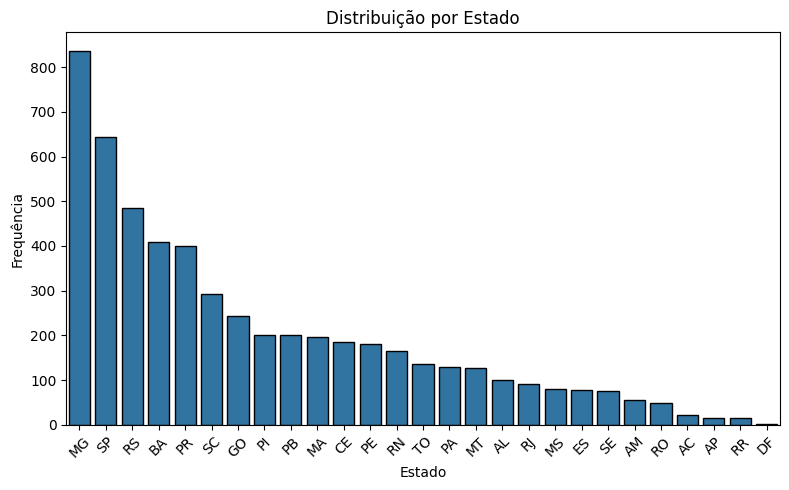

In [99]:
# =========================================================
# g) GRÁFICO - QUALITATIVA
# =========================================================

# Qualitativa frequencia popuplacao (barras)
plt.figure(figsize=(8,5))

sns.barplot(x=tabela_qualitativa.index,
            y=tabela_qualitativa['Frequência'],
            edgecolor="black",
            linewidth=1.0)
plt.title("Distribuição por Estado")
plt.tick_params(axis='x', rotation=45)
plt.xlabel("Estado")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

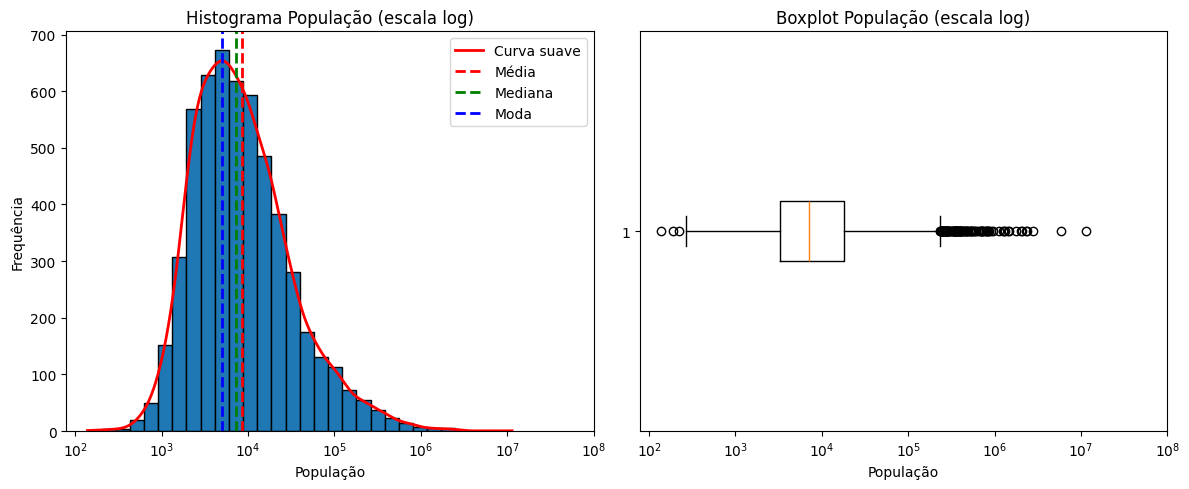

In [100]:
# =========================================================
# g) GRÁFICO - DISCRETA
# =========================================================

# Dados (garantindo positivos para log)
dados = df[df[discreta] > 0][discreta]
x = np.log10(dados)

# Medidas na escala log10
media = np.mean(x)
mediana = np.median(x)

# Moda aproximada via histograma
counts_hist, bins_hist = np.histogram(x, bins=30)
idx_moda = np.argmax(counts_hist)
moda = (bins_hist[idx_moda] + bins_hist[idx_moda+1]) / 2

# Figura
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Histograma (frequência)
counts, bins, _ = axs[0].hist(x, bins=30, edgecolor="black", linewidth=1.0)

# KDE (curva suave escalada)
kde = gaussian_kde(x)
xx = np.linspace(min(x), max(x), 500)

bin_width = bins[1] - bins[0]
kde_scaled = kde(xx) * len(x) * bin_width

axs[0].plot(xx, kde_scaled, color="red", linewidth=2, label="Curva suave")

# Linhas das medidas
axs[0].axvline(media, color="red", linestyle="--", linewidth=2, label="Média")
axs[0].axvline(mediana, color="green", linestyle="--", linewidth=2, label="Mediana")
axs[0].axvline(moda, color="blue", linestyle="--", linewidth=2, label="Moda")

# Formatação do eixo X (log -> valor real)
def log_to_power(val, pos):
    return rf"$10^{{{int(val)}}}$"

axs[0].xaxis.set_major_formatter(FuncFormatter(log_to_power))

# ticks em potências de 10
axs[0].set_xticks(np.arange(np.floor(min(x)), np.ceil(max(x))+1))

axs[0].set_title("Histograma População (escala log)")
axs[0].set_xlabel("População")
axs[0].set_ylabel("Frequência")
axs[0].legend()

# Boxplot
axs[1].boxplot(x, vert=False)

axs[1].xaxis.set_major_formatter(FuncFormatter(log_to_power))
axs[1].set_xticks(np.arange(np.floor(min(x)), np.ceil(max(x))+1))
axs[1].set_title("Boxplot População (escala log)")
axs[1].set_xlabel("População")

# Layout
plt.tight_layout()
plt.show()

/tmp/ipykernel_1419/3811711471.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


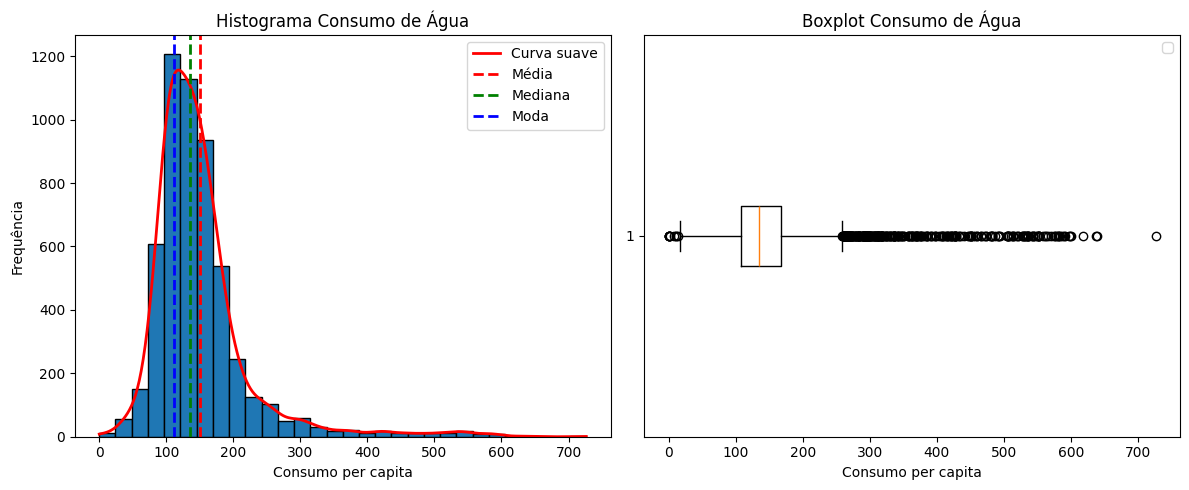

In [101]:
# =========================================================
# g) GRÁFICOS - CONTÍNUA
# =========================================================

# medidas
media = medidas_continua['medidas']['media']
mediana = medidas_continua['medidas']['mediana']
moda = medidas_continua['medidas']['moda']

# Dados
x = df[continua]

fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Histograma em frequência
counts, bins, _ = axs[0].hist(x, bins=30, edgecolor="black", linewidth=1.0)

# KDE
kde = gaussian_kde(x)
xx = np.linspace(min(x), max(x), 500)

# largura média dos bins
bin_width = bins[1] - bins[0]

# Escalando KDE para ficar em frequência
kde_scaled = kde(xx) * len(x) * bin_width

# Curva suave
axs[0].plot(xx, kde_scaled, color="red", linewidth=2, label="Curva suave")

# Histograma
#axs[0].hist(df[continua], bins=30, edgecolor="black", linewidth=1.0)
axs[0].set_title("Histograma Consumo de Água")
axs[0].set_xlabel("Consumo per capita")
axs[0].set_ylabel("Frequência")

# Linhas das medidas no histograma
axs[0].axvline(media, color="red", linestyle="--", linewidth=2, label="Média")
axs[0].axvline(mediana, color="green", linestyle="--", linewidth=2, label="Mediana")
axs[0].axvline(moda, color="blue", linestyle="--", linewidth=2, label="Moda")

axs[0].legend()

# Boxplot
axs[1].boxplot(x, vert=False)
axs[1].set_title("Boxplot Consumo de Água")
axs[1].set_xlabel("Consumo per capita")

axs[1].legend()

plt.tight_layout()
plt.show()